# 07 Cost-Sensitive XGBoost Tuning

This notebook keeps the `v2_full` preprocessing fixed and tunes the **model on top of those fixed features**.

So this is not another preprocessing ablation. The feature engineering is already chosen. The question now is whether a cost-sensitive XGBoost configuration can beat the earlier untuned `v2_full` reference on the same time-based validation design.

Business logic first:

- `false negative`: a real fraud case that the model misses
- `false positive`: a legitimate transaction that gets flagged and can still go through a confirmation or review step

That means it is reasonable to make fraud misses more costly. In this notebook that cost-sensitive behavior is implemented by increasing the effective positive-class weight through `scale_pos_weight`.


In [1]:
from pathlib import Path
import json
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import shap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.fraud_detection.cost_sensitive_experiments import (
    PRIMARY_METRIC,
    SECONDARY_METRICS,
    DIAGNOSTIC_METRICS,
    build_run_summary,
    build_shap_diagnostics,
    fit_cost_sensitive_xgboost,
    prepare_cost_sensitive_data,
    run_named_configs,
    run_weight_sweep,
)
from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 80_000
RANDOM_STATE = 42
SHAP_SAMPLE_SIZE = 1_200
WEIGHT_MULTIPLIERS = [0.4, 0.5, 0.6]
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Evaluation Setup

The notebook uses a business-facing ranking objective rather than optimizing only for a single generic metric.

- `Primary metric`: `Precision@Top3%`
- `Secondary metrics`: `Recall@Top3%`, `Average Precision`
- `Diagnostics`: `Precision@Top1%`, `Precision@Top5%`, `ROC-AUC`


In [2]:
data_bundle = prepare_cost_sensitive_data(
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

run_summary = build_run_summary(data_bundle)
display(run_summary.style.hide(axis="index"))

print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Secondary metrics: {', '.join(SECONDARY_METRICS)}")
print(f"Diagnostics: {', '.join(DIAGNOSTIC_METRICS)}")


item,value
sample_rows,80000.000000
train_rows,64000.000000
validation_rows,16000.000000
train_fraud_rate,0.035562
validation_fraud_rate,0.035687
base_scale_pos_weight,27.119508
feature_count,807.000000


Primary metric: precision_at_top_3pct
Secondary metrics: recall_at_top_3pct, average_precision
Diagnostics: precision_at_top_1pct, precision_at_top_5pct, roc_auc


## Untuned `v2_full` Reference

Before tuning anything, it helps to pin down the untuned `v2_full` reference. This run uses the same fixed `v2_full` feature set as the rest of the notebook and mirrors the earlier `06` style XGBoost setup as closely as possible.

That way the final conclusion can answer the question that matters most: is the best cost-sensitive model actually better than the earlier untuned `v2_full` baseline?


In [3]:
reference_result = fit_cost_sensitive_xgboost(
    data_bundle,
    pos_weight_multiplier=1.0,
    label="v2_full_reference_untuned",
    param_overrides={
        "n_estimators": 400,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "min_child_weight": 1,
        "reg_alpha": 0.0,
        "gamma": 0.0,
    },
)

reference_row = reference_result["row"]
display(
    pd.DataFrame([reference_row])[
        [
            "label",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

previous_v2_results_path = OUTPUT_DIR / "tree_ablation_v2_results.json"
if previous_v2_results_path.exists():
    previous_v2_results = pd.DataFrame(json.loads(previous_v2_results_path.read_text(encoding="utf-8")))
    display(previous_v2_results.style.hide(axis="index"))


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc,scale_pos_weight
v2_full_reference_untuned,0.525000,0.441331,0.472785,0.850000,0.373750,0.891387,27.119508


variant,roc_auc,average_precision,precision_at_top_5pct,recall_at_top_5pct,n_features
v2_core,0.913423,0.550732,0.413548,0.600886,462
v2_plus_missing_flags,0.914340,0.552034,0.416427,0.605069,792
v2_full,0.911789,0.553101,0.412024,0.598671,807


## Step 1: Narrow Cost-Sensitive Sweep

The first step only tunes the fraud-class weight. It does not touch the rest of the model capacity.

- `base_ratio = n_negative / n_positive`
- `scale_pos_weight = base_ratio * multiplier`

Here the notebook only checks `0.4`, `0.5`, and `0.6`.


label,pos_weight_multiplier,scale_pos_weight,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
weight_x0.6,0.600000,16.271705,0.522917,0.439580,0.480077,0.812500,0.393750,0.892649
weight_x0.4,0.400000,10.847803,0.520833,0.437828,0.484277,0.856250,0.393750,0.892940
weight_x0.5,0.500000,13.559754,0.512500,0.430823,0.475729,0.825000,0.387500,0.895498


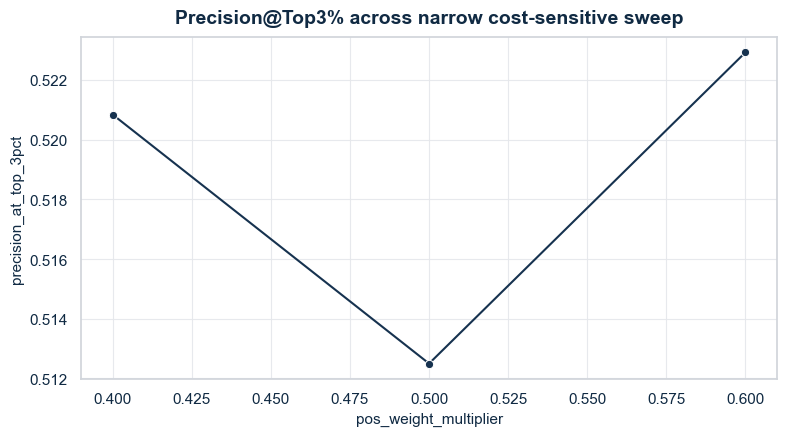

In [4]:
weight_results, weight_artifacts = run_weight_sweep(
    data_bundle,
    multipliers=WEIGHT_MULTIPLIERS,
)

display(
    weight_results[
        [
            "label",
            "pos_weight_multiplier",
            "scale_pos_weight",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
        ]
    ].style.hide(axis="index")
)

best_weight_row = weight_results.iloc[0]
best_weight_multiplier = float(best_weight_row["pos_weight_multiplier"])

plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=weight_results.sort_values("pos_weight_multiplier"),
    x="pos_weight_multiplier",
    y="precision_at_top_3pct",
    marker="o",
    color=PLOT_COLORS["navy"],
)
plt.title("Precision@Top3% across narrow cost-sensitive sweep")
plt.xlabel("pos_weight_multiplier")
plt.ylabel("precision_at_top_3pct")
plt.tight_layout()
plt.show()


## Step 2: Kaggle-Inspired Targeted Runs

Instead of a large Cartesian search, the notebook tries a few named, high-probability tree configurations around the region that tends to work well in strong IEEE-CIS tree notebooks.


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,reg_alpha,gamma,scale_pos_weight
kaggle_style_more_capacity,0.558333,0.469352,0.495486,0.825000,0.400000,0.897487,800,7,0.030000,0.800000,0.700000,3.000000,2.000000,0.100000,0.000000,16.271705
kaggle_style_balanced,0.533333,0.448336,0.481605,0.850000,0.390000,0.894676,500,6,0.050000,0.800000,0.800000,5.000000,2.000000,0.000000,0.000000,16.271705
kaggle_style_conservative_sampling,0.516667,0.434326,0.476393,0.825000,0.385000,0.893329,700,5,0.030000,0.700000,0.600000,5.000000,5.000000,0.100000,0.000000,16.271705
kaggle_style_stronger_regularization,0.516667,0.434326,0.475537,0.825000,0.387500,0.897981,600,5,0.050000,0.850000,0.800000,8.000000,10.000000,0.500000,0.500000,16.271705
kaggle_style_precision_push,0.508333,0.427320,0.461970,0.831250,0.376250,0.885747,450,4,0.080000,0.700000,0.600000,8.000000,5.000000,1.000000,1.000000,16.271705


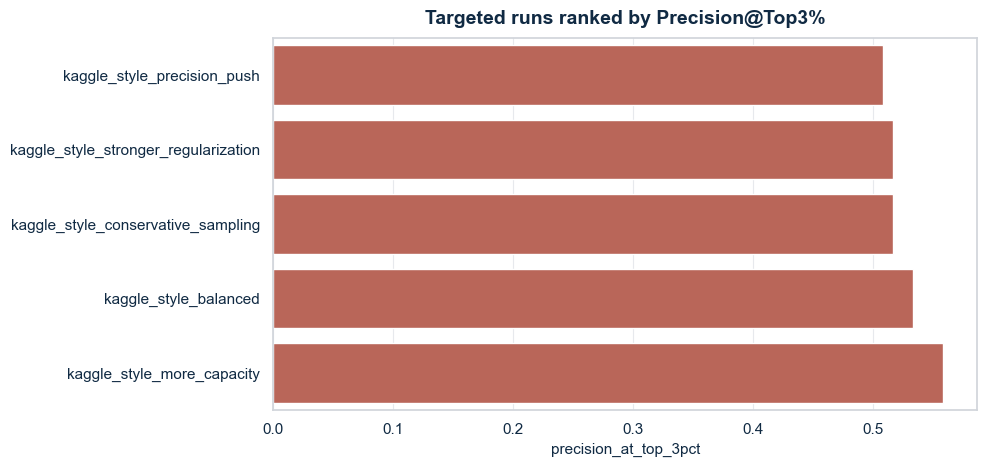

In [5]:
targeted_configs = [
    {
        "label": "kaggle_style_balanced",
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "min_child_weight": 5,
            "reg_lambda": 2.0,
            "reg_alpha": 0.0,
            "gamma": 0.0,
        },
    },
    {
        "label": "kaggle_style_conservative_sampling",
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": 700,
            "max_depth": 5,
            "learning_rate": 0.03,
            "subsample": 0.7,
            "colsample_bytree": 0.6,
            "min_child_weight": 5,
            "reg_lambda": 5.0,
            "reg_alpha": 0.1,
            "gamma": 0.0,
        },
    },
    {
        "label": "kaggle_style_more_capacity",
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": 800,
            "max_depth": 7,
            "learning_rate": 0.03,
            "subsample": 0.8,
            "colsample_bytree": 0.7,
            "min_child_weight": 3,
            "reg_lambda": 2.0,
            "reg_alpha": 0.1,
            "gamma": 0.0,
        },
    },
    {
        "label": "kaggle_style_stronger_regularization",
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": 600,
            "max_depth": 5,
            "learning_rate": 0.05,
            "subsample": 0.85,
            "colsample_bytree": 0.8,
            "min_child_weight": 8,
            "reg_lambda": 10.0,
            "reg_alpha": 0.5,
            "gamma": 0.5,
        },
    },
    {
        "label": "kaggle_style_precision_push",
        "pos_weight_multiplier": best_weight_multiplier,
        "params": {
            "n_estimators": 450,
            "max_depth": 4,
            "learning_rate": 0.08,
            "subsample": 0.7,
            "colsample_bytree": 0.6,
            "min_child_weight": 8,
            "reg_lambda": 5.0,
            "reg_alpha": 1.0,
            "gamma": 1.0,
        },
    },
]

targeted_results, targeted_artifacts = run_named_configs(
    data_bundle,
    configs=targeted_configs,
)

display(
    targeted_results[
        [
            "label",
            "precision_at_top_3pct",
            "recall_at_top_3pct",
            "average_precision",
            "precision_at_top_1pct",
            "precision_at_top_5pct",
            "roc_auc",
            "n_estimators",
            "max_depth",
            "learning_rate",
            "subsample",
            "colsample_bytree",
            "min_child_weight",
            "reg_lambda",
            "reg_alpha",
            "gamma",
            "scale_pos_weight",
        ]
    ].style.hide(axis="index")
)

best_targeted_row = targeted_results.iloc[0]
best_targeted_result = targeted_artifacts[best_targeted_row["label"]]

plt.figure(figsize=(10, 4.8))
sns.barplot(
    data=targeted_results.iloc[::-1],
    x="precision_at_top_3pct",
    y="label",
    color=PLOT_COLORS["coral"],
)
plt.title("Targeted runs ranked by Precision@Top3%")
plt.xlabel("precision_at_top_3pct")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Final Comparison: Did The Tuned Model Actually Beat The Earlier `v2_full` Reference?

This is the most important summary view in the notebook. It puts the final tuned winner directly beside the untuned `v2_full` reference.


label,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
v2_full_reference_untuned,0.525000,0.441331,0.472785,0.850000,0.373750,0.891387
kaggle_style_more_capacity,0.558333,0.469352,0.495486,0.825000,0.400000,0.897487


comparison,precision_at_top_3pct,recall_at_top_3pct,average_precision,precision_at_top_1pct,precision_at_top_5pct,roc_auc
best_targeted_minus_reference,0.033333,0.028021,0.022701,-0.025000,0.026250,0.006101


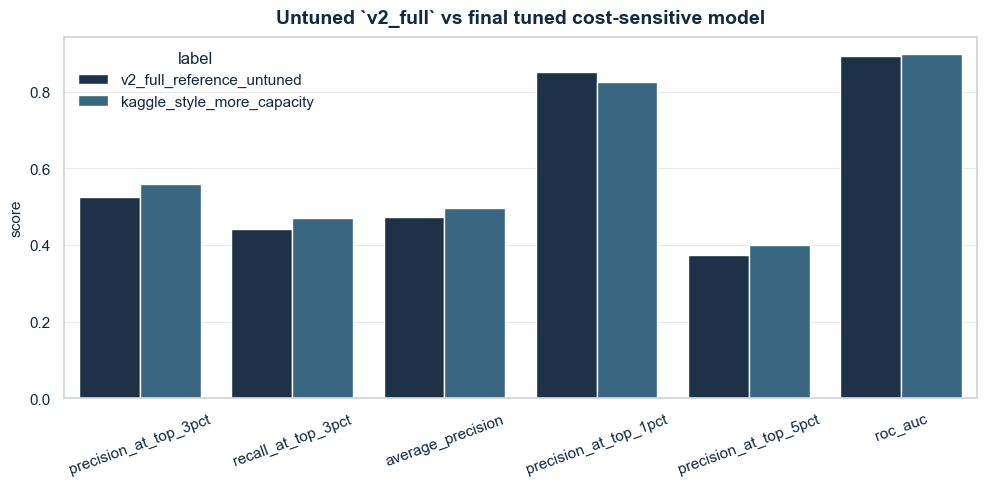

In [6]:
final_comparison = pd.DataFrame(
    [reference_row, best_targeted_result["row"]]
)[[
    "label",
    "precision_at_top_3pct",
    "recall_at_top_3pct",
    "average_precision",
    "precision_at_top_1pct",
    "precision_at_top_5pct",
    "roc_auc",
]]

display(final_comparison.style.hide(axis="index"))

delta_row = {
    "comparison": "best_targeted_minus_reference",
    "precision_at_top_3pct": best_targeted_result["row"]["precision_at_top_3pct"] - reference_row["precision_at_top_3pct"],
    "recall_at_top_3pct": best_targeted_result["row"]["recall_at_top_3pct"] - reference_row["recall_at_top_3pct"],
    "average_precision": best_targeted_result["row"]["average_precision"] - reference_row["average_precision"],
    "precision_at_top_1pct": best_targeted_result["row"]["precision_at_top_1pct"] - reference_row["precision_at_top_1pct"],
    "precision_at_top_5pct": best_targeted_result["row"]["precision_at_top_5pct"] - reference_row["precision_at_top_5pct"],
    "roc_auc": best_targeted_result["row"]["roc_auc"] - reference_row["roc_auc"],
}
display(pd.DataFrame([delta_row]).style.hide(axis="index"))

comparison_plot = final_comparison.melt(id_vars="label", var_name="metric", value_name="value")
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x="metric", y="value", hue="label")
plt.title("Untuned `v2_full` vs final tuned cost-sensitive model")
plt.xlabel("")
plt.ylabel("score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## SHAP For The Final Selected Model

The main SHAP view below is the standard dot-style summary plot, which is the one that looks like a cloud of small points. That is usually the most recognizable global SHAP plot. A simple dependence plot is kept after it as a supporting view.


item,value
best_weight_label,weight_x0.6
best_targeted_label,kaggle_style_more_capacity
rows_used_for_shap,1200
top_feature_for_dependence_view,TransactionDay


feature,mean_abs_shap
TransactionDay,0.265625
card6__count,0.182345
C13,0.171840
TransactionAmt_diff_mean_addr1,0.168563
C14,0.159605
D3,0.155585
TransactionDT,0.154464
C1,0.142690
card2,0.125485
TransactionAmt_to_mean_addr1,0.122941


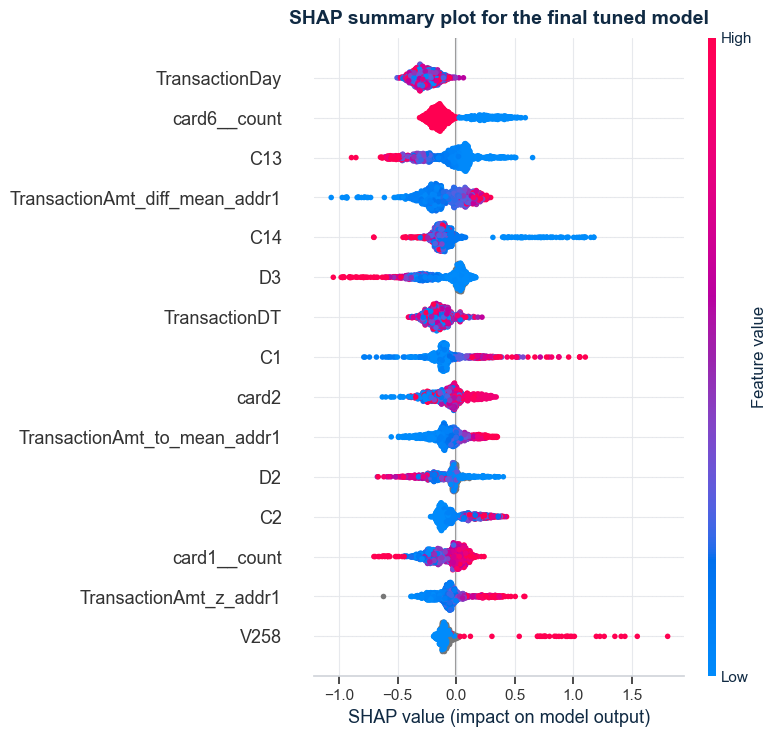

In [7]:
shap_pack = build_shap_diagnostics(
    best_targeted_result["model"],
    data_bundle.x_valid,
    data_bundle.y_valid,
    sample_size=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

display(
    pd.DataFrame(
        [
            {"item": "best_weight_label", "value": best_weight_row["label"]},
            {"item": "best_targeted_label", "value": best_targeted_row["label"]},
            {"item": "rows_used_for_shap", "value": shap_pack["row_count"]},
            {"item": "top_feature_for_dependence_view", "value": shap_pack["top_feature"]},
        ]
    ).style.hide(axis="index")
)

display(shap_pack["importance"].style.hide(axis="index"))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_pack["shap_matrix"],
    shap_pack["x_sample"],
    show=False,
    max_display=15,
)
plt.title("SHAP summary plot for the final tuned model")
plt.tight_layout()
plt.show()


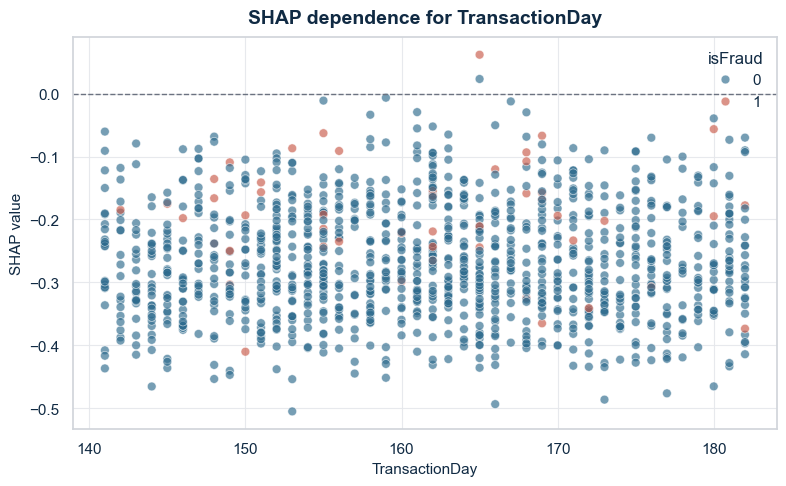

In [8]:
dependence_frame = shap_pack["dependence_frame"]
plt.figure(figsize=(8, 5))
if dependence_frame.empty:
    plt.text(0.5, 0.5, "No usable numeric values were available for the dependence view.", ha="center", va="center", wrap=True)
    plt.axis("off")
else:
    sns.scatterplot(
        data=dependence_frame,
        x=shap_pack["top_feature"],
        y="shap_value",
        hue="isFraud",
        palette={0: PLOT_COLORS["blue"], 1: PLOT_COLORS["coral"]},
        alpha=0.65,
        s=40,
    )
    plt.axhline(0, linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
    plt.title(f"SHAP dependence for {shap_pack['top_feature']}")
    plt.xlabel(shap_pack["top_feature"])
    plt.ylabel("SHAP value")
    plt.legend(title="isFraud")
plt.tight_layout()
plt.show()


In [9]:
weight_results.to_csv(OUTPUT_DIR / "cost_sensitive_weight_sweep.csv", index=False)
targeted_results.to_csv(OUTPUT_DIR / "cost_sensitive_targeted_runs.csv", index=False)

summary_payload = {
    "reference_run": reference_row,
    "best_weight_run": best_weight_row.to_dict(),
    "best_targeted_run": best_targeted_row.to_dict(),
    "delta_vs_reference": delta_row,
}
(OUTPUT_DIR / "cost_sensitive_tuning_summary.json").write_text(
    json.dumps(summary_payload, indent=2),
    encoding="utf-8",
)

print("Saved outputs/cost_sensitive_weight_sweep.csv")
print("Saved outputs/cost_sensitive_targeted_runs.csv")
print("Saved outputs/cost_sensitive_tuning_summary.json")


Saved outputs/cost_sensitive_weight_sweep.csv
Saved outputs/cost_sensitive_targeted_runs.csv
Saved outputs/cost_sensitive_tuning_summary.json


## Reading The Result

A clean takeaway structure is:

- state clearly that this notebook tunes the model on fixed `v2_full` features
- show the untuned `v2_full` reference first
- show the best cost-sensitive tuned run beside that reference
- then use the SHAP dot summary plot to explain what the final winner is using
